In [1]:
# ─────────────────────────────────────────────
# [종합 점검] 오늘 갖춘 환경이 모두 정상인지 한 번에 확인
# ─────────────────────────────────────────────
import sys, platform, shutil

checks = []

# 1) Python 동작
checks.append(("Python 실행", True, platform.python_version()))

# 2) 핵심 라이브러리
for name in ["numpy", "pandas", "matplotlib", "jupyter_core"]:
    try:
        mod = __import__(name)
        ver = getattr(mod, "__version__", "ok")
        checks.append((f"{name} 설치", True, str(ver)))
    except Exception:
        checks.append((f"{name} 설치", False, "미설치"))

# 3) Git 설치
git_path = shutil.which("git")
checks.append(("Git 설치", git_path is not None, git_path or "없음"))

# 4) myenv 커널 여부(실행 경로에 myenv 포함?)
in_myenv = "myenv" in sys.executable.lower()
checks.append(("myenv 커널 사용", in_myenv, sys.executable))

print("=" * 52)
print(" 오늘의 환경 점검표")
print("=" * 52)
for name, ok, detail in checks:
    mark = "✅" if ok else "⚠️"
    print(f"{mark}  {name:<16} | {detail}")
print("=" * 52)

passed = sum(1 for _, ok, _ in checks if ok)
print(f"\n통과: {passed}/{len(checks)}")
if passed == len(checks):
    print("완벽합니다! 모든 준비가 끝났어요. 🎉")
else:
    print("⚠️ 표시된 항목을 위 Part로 돌아가 다시 확인해보세요. (myenv 커널은 Part 4 참고)")

 오늘의 환경 점검표
✅  Python 실행        | 3.11.15
✅  numpy 설치         | 2.4.6
✅  pandas 설치        | 3.0.3
✅  matplotlib 설치    | 3.11.0
✅  jupyter_core 설치  | 5.9.1
✅  Git 설치           | C:\Program Files\Git\cmd\git.EXE
✅  myenv 커널 사용      | c:\Users\spide\anaconda3\envs\myenv\python.exe

통과: 7/7
완벽합니다! 모든 준비가 끝났어요. 🎉


In [ ]:
!pip install numpy pandas matplotlib seaborn -q

In [3]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas matplotlib seaborn -q


import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3


In [47]:
# 공공데이터 스타일 데이터 생성 (따릉이 일별 대여 기록 — 가상)
np.random.seed(7)
n_days = 180
dates = pd.date_range("2025-01-01", periods=n_days, freq="D")
# 계절성: 봄·여름에 대여 증가
seasonal = 3000 + 2500 * np.sin(np.linspace(0, np.pi, n_days))
rentals = (seasonal + np.random.normal(0, 400, n_days)).round().astype(int)

bike = pd.DataFrame({
    "date": dates,
    "rentals": rentals,
    "avg_temp": (np.linspace(-2, 28, n_days) + np.random.normal(0, 2, n_days)).round(1),
    "rainfall": np.random.choice([0, 0, 0, 0, 5, 12, 30], n_days),
    "station_area": np.random.choice(["강남", "마포", "송파", "종로", " 강남 "], n_days),
})
# 오염 심기: 대여수 결측, 기온 이상치, 중복 행
bike.loc[np.random.choice(n_days, 8, replace=False), "rentals"] = np.nan
bike.loc[50, "avg_temp"] = 250.0     # 센서 오류로 보이는 이상치
bike = pd.concat([bike, bike.iloc[[3]]], ignore_index=True)  # 중복 1건

print("따릉이 데이터 준비 완료:", bike.shape)
bike.head()

따릉이 데이터 준비 완료: (181, 5)


,date,rentals,avg_temp,rainfall,station_area
0,2025-01-01,3676.0,-3.0,12,마포
1,2025-01-02,2857.0,-1.1,0,마포
2,2025-01-03,3101.0,-1.1,0,강남
3,2025-01-04,3295.0,0.9,0,강남
4,2025-01-05,2860.0,-1.1,0,마포


In [33]:
# 시나리오 1 — 구조 진단
print("shape:", bike.shape)
bike.info()
display(bike.describe())

shape: (181, 5)
<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          181 non-null    datetime64[us]
 1   rentals       173 non-null    float64       
 2   avg_temp      181 non-null    float64       
 3   rainfall      181 non-null    int64         
 4   station_area  181 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 7.2 KB


,date,rentals,avg_temp,rainfall
count,181,173.000000,181.000000,181.000000
mean,2025-03-31 00:31:49.392265,4531.757225,14.169061,5.298343
min,2025-01-01 00:00:00,2514.000000,-4.900000,0.000000
25%,2025-02-14 00:00:00,3841.000000,5.100000,0.000000
50%,2025-03-31 00:00:00,4708.000000,13.100000,0.000000
75%,2025-05-15 00:00:00,5243.000000,20.600000,5.000000
max,2025-06-29 00:00:00,6388.000000,250.000000,30.000000
std,NaN,889.609013,19.742786,9.687303


In [48]:
# 시나리오 2 — 품질 진단
print("[결측치]")
print(bike.isnull().sum())
print("\n중복 행:", bike.duplicated().sum())
print("\n[station_area 값의 종류]")
print(bike["station_area"].unique())
print("\n기온 이상치 확인(상위 3개):")
print(bike["avg_temp"].sort_values(ascending=False).head(3).tolist())
print("\n강수량 이상치 확인(상위 3개):")
print(bike["rainfall"].sort_values(ascending=False).head(3).tolist())

[결측치]
date            0
rentals         8
avg_temp        0
rainfall        0
station_area    0
dtype: int64

중복 행: 1

[station_area 값의 종류]
<StringArray>
['마포', ' 강남 ', '강남', '송파', '종로']
Length: 5, dtype: str

기온 이상치 확인(상위 3개):
[250.0, 31.8, 30.6]

강수량 이상치 확인(상위 3개):
[30, 30, 30]


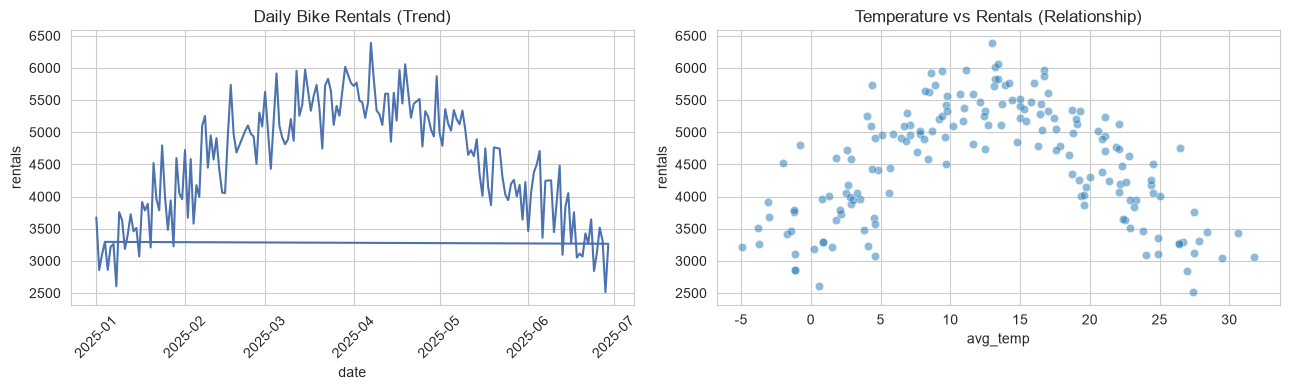

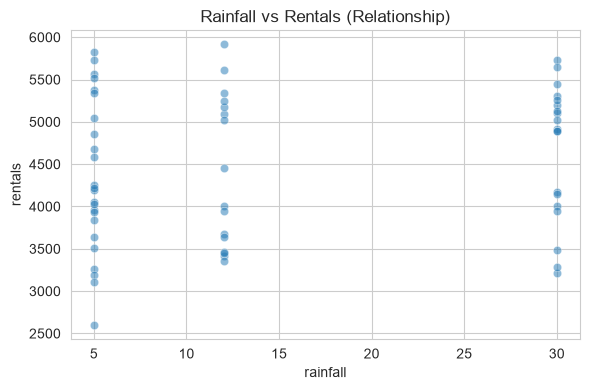

In [46]:
# 시나리오 3 — 시각화 (이상치 제거 후)
clean = bike[(bike["avg_temp"] < 60)].dropna(subset=["rentals"])
clean2 = bike[(bike["rainfall"] > 0)].dropna(subset=["rentals"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# 추이
axes[0].plot(clean["date"], clean["rentals"], color="#4C72B0")
axes[0].set_title("Daily Bike Rentals (Trend)")
axes[0].set_xlabel("date"); axes[0].set_ylabel("rentals")
axes[0].tick_params(axis="x", rotation=45)
# 관계
sns.scatterplot(data=clean, x="avg_temp", y="rentals", alpha=0.5, ax=axes[1])
axes[1].set_title("Temperature vs Rentals (Relationship)")
axes[1].set_xlabel("avg_temp"); axes[1].set_ylabel("rentals")
plt.tight_layout(); plt.show()
# rainfall 와 rentals의 관계(추가) 
fig2, ax2 = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=clean2, x="rainfall", y="rentals", alpha=0.5, ax=ax2)
ax2.set_title("Rainfall vs Rentals (Relationship)")
ax2.set_xlabel("rainfall"); ax2.set_ylabel("rentals")
plt.tight_layout(); plt.show()
